# Levelling to a grid

In [1]:
%load_ext autoreload
%autoreload 2

import bordado as bd
import boule
import cmocean
import numpy as np
import pandas as pd
import pooch
import pyproj
import verde as vd
import xarray as xr

import airbornegeo

## Load survey data

This is a subset of the BAS AGAP survey over Antarctica's Gamburtsev Subglacial Mountains. The file is download and subset in the notebook `AGAP_gravity_survey`, and the BAS processing steps are repeated in the notebook `processing_AGAP_gravity_survey`.

In [2]:
data_df = pd.read_csv("data/AGAP_gravity_survey_processed.csv")
data_df = data_df[
    [
        "easting",
        "northing",
        "height",
        "line",
        "unixtime",
        "distance_along_line",
        "grav_disturbance_filt",
    ]
]
data_df.head()

,easting,northing,height,line,unixtime,distance_along_line,grav_disturbance_filt
0,1.000024e+06,226237.330771,4156.1,1,1.229507e+09,0.000000,49.38
1,1.000083e+06,226246.631269,4156.0,1,1.229507e+09,59.842447,49.45
2,1.000142e+06,226255.809132,4156.1,1,1.229507e+09,119.693401,49.52
3,1.000201e+06,226264.969079,4156.4,1,1.229507e+09,179.545645,49.58
4,1.000260e+06,226274.156809,4156.6,1,1.229507e+09,239.285174,49.65


In [ ]:
# Wrap data into a Survey, storing column names for reuse
survey = airbornegeo.Survey(
    data_df,
    line_column="line",
    distance_column="distance_along_line",
)
survey

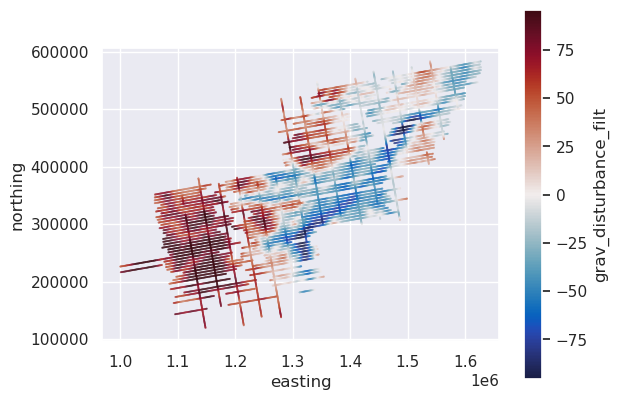

In [3]:
# plot the data
max_abs = vd.maxabs(data_df.grav_disturbance_filt, percentile=95)
ax = data_df[::20].plot.scatter(
    "easting",
    "northing",
    c="grav_disturbance_filt",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

## Get a grid of gravity disturbance at 10km

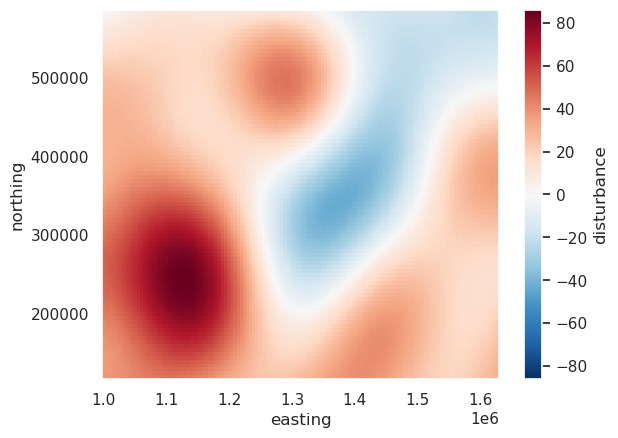

In [4]:
# Download satellite gravity data from EIGEN-6C4 model
path = pooch.retrieve(
    url="doi:10.5281/zenodo.5882207/earth-gravity-10arcmin.nc",
    known_hash="d55134501da0d984f318c0f92e1a15a8472176ec7babde5edfdb58855190273e",
    progressbar=True,
)
grid = xr.load_dataset(path)

# add height as variable
grid["ellipsoidal_height"] = xr.full_like(grid.gravity, 10e3)


# subset to geographic region of interest
region = bd.get_region((data_df.easting, data_df.northing))
region_pad = bd.pad_region(region, 20e3)
transformer = pyproj.Transformer.from_crs("epsg:3031", "epsg:4326")
region_geo = transformer.transform_bounds(
    left=region_pad[0],
    bottom=region_pad[2],
    right=region_pad[1],
    top=region_pad[3],
)
grid = grid.sel(
    latitude=slice(region_geo[0], region_geo[2]),
    longitude=slice(region_geo[1], region_geo[3]),
)


# calculated normal gravity at all EIGEN observation locations
grid["normal_gravity"] = boule.WGS84.normal_gravity(
    (None, grid.latitude, grid.ellipsoidal_height),
)

# calculate gravity disturbance
grid["disturbance"] = grid.gravity - grid.normal_gravity

# reproject to polar stereographic
eigen_disturbance = vd.project_grid(
    grid.disturbance,
    projection=pyproj.Proj("epsg:3031"),
    spacing=5e3,
    region=region,
)
eigen_disturbance.plot()

## Upward continue survey data to same height as gravity grid

In order to accurately compare the survey gravity data to the grid, the gravity data should be upward continued so it's at the same altitude.

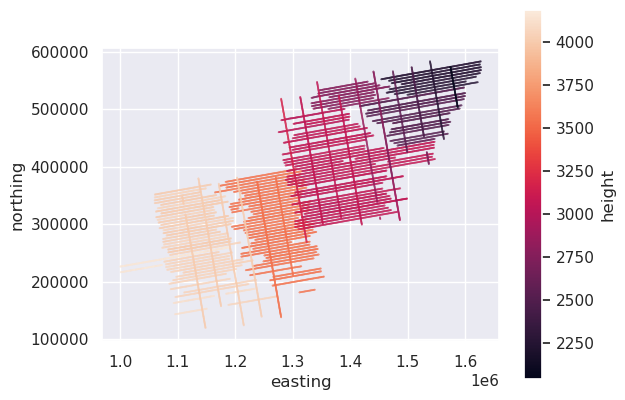

In [5]:
# plot the data
ax = data_df[::20].plot.scatter(
    "easting",
    "northing",
    c="height",
    s=0.1,
)
ax.set_aspect("equal")

In [ ]:
blocked_survey = survey.block_reduce(
    np.median,
    spacing=1000,
    reduce_by="distance_along_line",
)
blocked_survey

In [ ]:
# fit a set of equivalent sources to each line individually
eqs = blocked_survey.eq_sources_1d(
    data_column="grav_disturbance_filt",
    damping=None,
    block_size=1000,  # for speed, block reduce sources
)
eqs

In [ ]:
# upward continue each line to 10 km (height of EIGEN disturbance)
blocked_survey.upward_continue_by_line(
    eqs,
    10e3,
    result_column="upward_continued_10km",
)
blocked_survey.head()

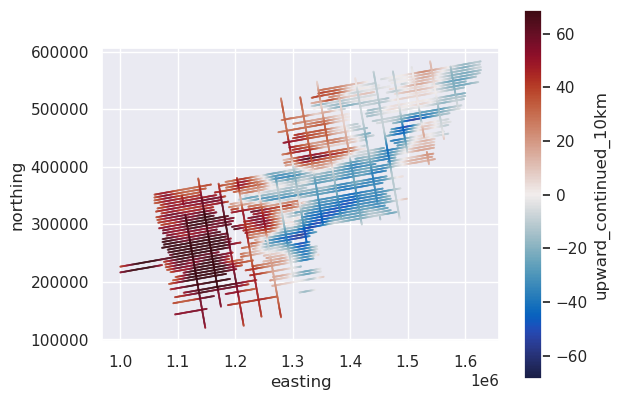

In [9]:
# plot the upward continued data
max_abs = vd.maxabs(blocked_survey.upward_continued_10km, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="upward_continued_10km",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

### Sample the satellite gravity grid values into the dataframe

In [ ]:
# sample grid along lines
blocked_survey.sample_grid(
    eigen_disturbance,
    result_column="sampled_satellite_values",
)
blocked_survey.head()

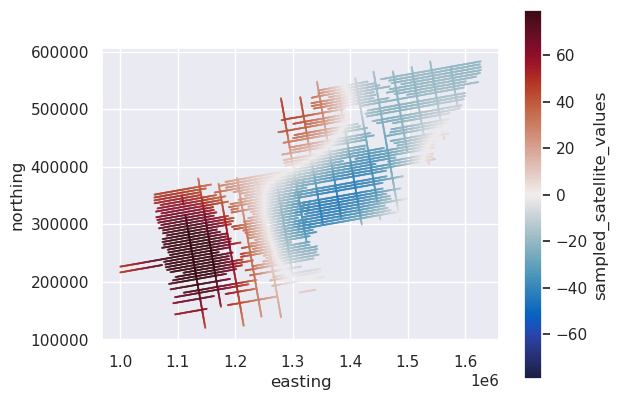

In [11]:
# plot the sampled grid values
max_abs = vd.maxabs(blocked_survey.sampled_satellite_values, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="sampled_satellite_values",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

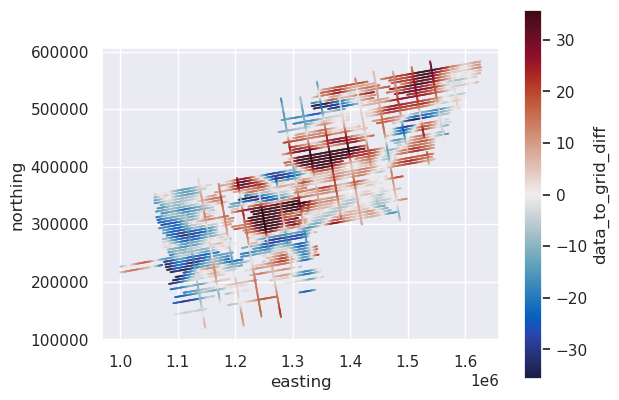

In [12]:
# plot the difference
blocked_survey["data_to_grid_diff"] = (
    blocked_survey.upward_continued_10km - blocked_survey.sampled_satellite_values
)
max_abs = vd.maxabs(blocked_survey.data_to_grid_diff, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="data_to_grid_diff",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

## Level the lines to the grid

In [ ]:
blocked_survey.level_to_grid(
    data_column="upward_continued_10km",
    grid_column="sampled_satellite_values",
    result_column="levelled_trend_0",
    fit_by_column="distance_along_line",
    degree=0,  # DC shift
)
blocked_survey.head()

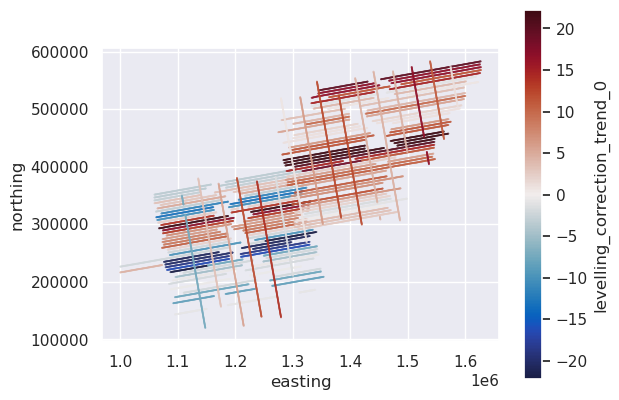

In [14]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_0"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_0
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_0, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_0",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

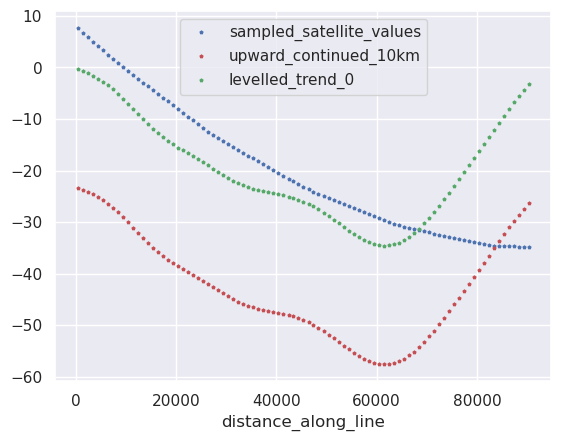

In [15]:
# look at just 1 of the leveled lines
line_df = blocked_survey[blocked_survey.line == 2]
ax = line_df.plot.line(
    "distance_along_line",
    "sampled_satellite_values",
    style="bp",
    ms=2,
)
ax = line_df.plot.line(
    "distance_along_line",
    "upward_continued_10km",
    style="rp",
    ms=2,
    ax=ax,
)
ax = line_df.plot.line(
    "distance_along_line",
    "levelled_trend_0",
    style="gp",
    ms=2,
    ax=ax,
)

## Level the entire survey to the grid

Instead of levelling each line individually to the grid, we can level the entire survey together to the grid. To do this, we don't supply the `groupby_column` argument, and choose the coordinate columns for the the `fit_by_column` argument.

In [ ]:
blocked_survey.level_to_grid(
    data_column="upward_continued_10km",
    grid_column="sampled_satellite_values",
    result_column="levelled_trend_1",
    fit_by_column=("easting", "northing"),  # fit trend based on coordinates
    degree=1,
).level_to_grid(
    data_column="upward_continued_10km",
    grid_column="sampled_satellite_values",
    result_column="levelled_trend_2",
    fit_by_column=("easting", "northing"),  # fit trend based on coordinates
    degree=2,
)
blocked_survey.head()

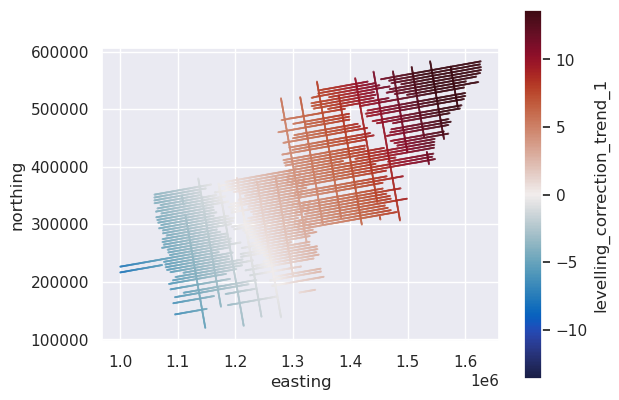

In [17]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_1"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_1
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_1, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_1",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")

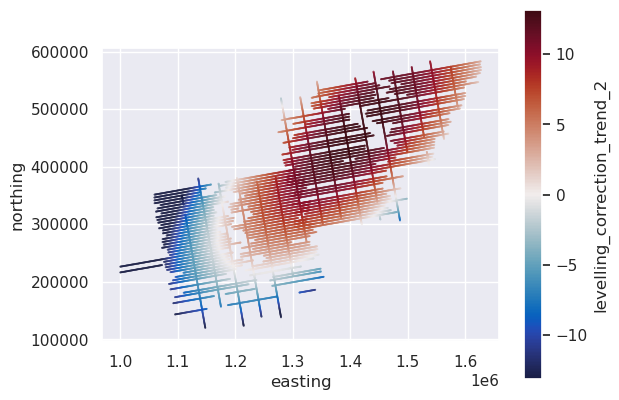

In [18]:
# plot the levelling correction
blocked_survey["levelling_correction_trend_2"] = (
    blocked_survey.upward_continued_10km - blocked_survey.levelled_trend_2
)
max_abs = vd.maxabs(blocked_survey.levelling_correction_trend_2, percentile=95)
ax = blocked_survey.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction_trend_2",
    s=0.1,
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
)
ax.set_aspect("equal")